# 03 — Walk-Forward Backtest: Full Metric Suite

Evaluates all trained models across the four walk-forward periods using
**six metrics** reported for every algorithm and every period.

---

## Metrics reported

| Metric | What it measures | Why it matters for NSE |
|--------|-----------------|----------------------|
| **Sharpe ratio** | Excess return per unit of total risk | Primary proposal metric — will be negative for most strategies given 13% T-bill + 4.16% costs |
| **Sortino ratio** | Excess return per unit of *downside* risk only | More appropriate than Sharpe for fat-tailed NSE returns — upside swings don't penalise you |
| **Max drawdown** | Largest peak-to-trough loss | Most important for retail investors who cannot recover from large losses |
| **Calmar ratio** | Annualised return / max drawdown | Rewards agents that earn returns without catastrophic losses |
| **Total return %** | Raw portfolio return over the episode | Baseline performance before risk adjustment |
| **Win rate %** | % of days with positive return | Simple, intuitive metric for the retail investor audience |

---

## Correct Sharpe computation — per episode, not averaged series

**Wrong:**
```python
avg_vals = np.mean([ep1, ep2, ep3, ...], axis=0)   # averages out variance
sharpe   = compute_sharpe(avg_vals)                  # denominator too small -> inflated
```

**Correct (what this notebook does):**
```python
sharpes = [episode_sharpe(ep) for ep in episodes]   # per episode
mean_sharpe = np.mean(sharpes)                       # true expected Sharpe
```

---

## NSE context — why negative Sharpe is a finding, not a failure

| Item | Value |
|---|---|
| Kenya T-bill (risk-free rate) | ~13% / year = 0.000487 / day |
| NSE round-trip cost | 4.16% |
| Gross return needed for Sharpe > 0 | **> 17.2% / year** |
| NSE 20 Index historical average | 5–8% / year |

The meaningful comparisons are:
1. **Agent vs equal-weight baseline** — does the agent add value over a simple strategy?
2. **Sharpe generalisation gap < 0.10** — is the strategy robust to unseen data?


In [1]:
import os, sys, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.insert(0, "..")

from stable_baselines3 import PPO, DQN, A2C
from environment.nse_env  import NSEPortfolioEnv
from evaluation.metrics   import (
    episode_sharpe,
    mean_episode_sharpe,
    sharpe_generalisation_gap,
    sortino_ratio,
    max_drawdown,
    calmar_ratio,
    all_metrics,
    sharpe_context_nse,
    RF_DAILY,
)

os.makedirs("plots", exist_ok=True)

ctx = sharpe_context_nse()
print("NSE Sharpe Context")
print("=" * 55)
for k, v in ctx.items():
    print(f"  {k:<40}: {v}")

NSE Sharpe Context
  rf_annual_pct                           : 12.27
  rf_daily                                : 0.000487
  nse_round_trip_pct                      : 4.16
  breakeven_gross_pct                     : 16.43
  nse20_avg_return_pct                    : 5-8
  expected_sharpe                         : negative for most strategies
  note                                    : Positive Sharpe on NSE is a genuine finding. The meaningful comparison is agent Sharpe vs equal-weight baseline Sharpe, not agent Sharpe vs zero.


In [2]:
import os
from pathlib import Path

# The models are saved in training/models/ not evaluation/models/
# We need to point to the training folder as our base

# Current location: nse_portfolio_rl/evaluation/
# Models location:  nse_portfolio_rl/training/models/

TRAINING_DIR = Path.cwd().parent / "training"
MODELS_DIR   = TRAINING_DIR / "models"

print("Current working directory:", Path.cwd())
print("Models directory:         ", MODELS_DIR)
print("Models directory exists:  ", MODELS_DIR.exists())
print()

# Verify all four algorithm folders are visible
for algo in ["ppo", "dqn", "a2c", "reinforce"]:
    p = MODELS_DIR / algo / "best_by_sharpe.zip"
    print(f"  {algo}: best_by_sharpe.zip exists = {p.exists()}")

Current working directory: c:\Users\Administrator\nse_portfolio_rl\evaluation
Models directory:          c:\Users\Administrator\nse_portfolio_rl\training\models
Models directory exists:   True

  ppo: best_by_sharpe.zip exists = True
  dqn: best_by_sharpe.zip exists = True
  a2c: best_by_sharpe.zip exists = True
  reinforce: best_by_sharpe.zip exists = True


## Load best model for each algorithm

Loads `best_by_sharpe.zip` — the checkpoint saved when validation Sharpe
was highest during training. Falls back to the most recent final model
if the Sharpe-selected checkpoint does not exist yet.


In [3]:
import os, glob
from pathlib import Path
from stable_baselines3 import PPO, DQN, A2C

TRAINING_DIR = Path.cwd().parent / "training"
MODELS_DIR   = TRAINING_DIR / "models"

ALGOS   = ["ppo", "dqn", "a2c", "reinforce"]
PERIODS = ["train", "val", "test1", "test2"]
PERIOD_LABELS = {
    "train": "Train (07-17)",
    "val":   "Val (18-20)",
    "test1": "Test1 (21-22)",
    "test2": "Test2 (23-25)",
}

def load_best(algo):
    sharpe_path = MODELS_DIR / algo / "best_by_sharpe.zip"
    final_paths = sorted((MODELS_DIR / algo).glob("*_final.zip"))

    if sharpe_path.exists():
        p = str(sharpe_path).replace(".zip", "")
        print(f"  {algo:<12}: loaded best_by_sharpe.zip")
    elif final_paths:
        p = str(final_paths[-1]).replace(".zip", "")
        print(f"  {algo:<12}: fallback -> {final_paths[-1].name}")
    else:
        print(f"  {algo:<12}: NO MODEL FOUND")
        return None

    if algo in ("ppo", "reinforce"):
        return PPO.load(p)
    elif algo == "dqn":
        return DQN.load(p)
    else:
        return A2C.load(p)

models = {a: load_best(a) for a in ALGOS}
models = {a: m for a, m in models.items() if m is not None}
print(f"\n{len(models)} models loaded.")

  ppo         : loaded best_by_sharpe.zip
  dqn         : loaded best_by_sharpe.zip
  a2c         : loaded best_by_sharpe.zip
  reinforce   : loaded best_by_sharpe.zip

4 models loaded.


## Evaluation function — all six metrics per period

Runs `n_episodes` episodes. For each episode collects the full value
history and computes all metrics from it. Reports mean across episodes.

`domain_randomise=False` keeps costs fixed at calibrated values
so results are reproducible.


In [4]:
def evaluate_with_fixed_seeds(model, period, n_episodes=100, seed=42):
    """
    Evaluate a model AND equal-weight baseline on identical episode
    start points for a fair apples-to-apples comparison.
    
    Returns dict with both model and baseline metrics.
    """
    from data.database         import get_db, ALL_TICKERS, N_STOCKS
    from environment.nse_env   import NSEPortfolioEnv
    from environment.nse_costs import NSECostModel

    # ── Generate fixed start points ──────────────────────────────────────
    np.random.seed(seed)
    db   = get_db()
    data = db.get_period(period)
    T    = data["T"]

    starts = [
        np.random.randint(65, max(66, T - 252))
        for _ in range(n_episodes)
    ]

    # ── Evaluate MODEL on fixed starts ───────────────────────────────────
    model_sharpes  = []
    model_returns  = []
    model_mdds     = []
    model_winrates = []

    env = NSEPortfolioEnv(period=period, domain_randomise=False)

    for start in starts:
        obs, _ = env.reset(start_t=start)   # pass fixed start
        done   = False
        values = [env.INITIAL_CAPITAL]

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, term, trunc, info = env.step(int(action))
            done = term or trunc
            values.append(info["portfolio_value"])

        if len(values) < 10:
            continue

        v = np.array(values)
        r = np.diff(v) / (v[:-1] + 1e-8)
        model_sharpes.append(episode_sharpe(values, RF_DAILY))
        model_returns.append((values[-1] / env.INITIAL_CAPITAL - 1) * 100)
        model_mdds.append(max_drawdown(values) * 100)
        model_winrates.append(float(np.mean(r > 0) * 100))

    env.close()

    # ── Evaluate EQUAL-WEIGHT on same fixed starts ───────────────────────
    costs      = NSECostModel()
    prices     = data["prices"]
    avail      = data["availability"]
    INITIAL    = 100_000.0

    ew_sharpes  = []
    ew_returns  = []
    ew_mdds     = []
    ew_winrates = []

    for start in starts:
        end = min(start + 252, T)
        av  = avail[start]
        na  = int(av.sum())

        if na == 0:
            continue

        w       = av / na
        capital = INITIAL

        buy_cost = sum(
            costs.compute_cost(capital * w[i])
            for i in range(N_STOCKS) if w[i] > 0
        )
        capital -= buy_cost
        values   = [capital]

        for t in range(start + 1, end):
            p_curr = np.where(np.isnan(prices[t]),   prices[t-1], prices[t])
            p_prev = np.where(np.isnan(prices[t-1]), p_curr,      prices[t-1])
            ret    = ((p_curr - p_prev) / (p_prev + 1e-8)) * avail[t]
            ret    = np.nan_to_num(ret, nan=0.0, posinf=0.0, neginf=0.0)
            capital *= (1 + float(np.dot(w, ret)))
            capital  = float(np.nan_to_num(capital, nan=0.01))
            values.append(capital)

        if len(values) < 10:
            continue

        v = np.array(values)
        r = np.diff(v) / (v[:-1] + 1e-8)
        ew_sharpes.append(episode_sharpe(values, RF_DAILY))
        ew_returns.append((values[-1] / INITIAL - 1) * 100)
        ew_mdds.append(max_drawdown(values) * 100)
        ew_winrates.append(float(np.mean(r > 0) * 100))

    # ── Build results dict ───────────────────────────────────────────────
    def safe_mean(lst):
        return round(float(np.mean(lst)), 4) if lst else 0.0

    results = {
        "period":     period,
        "n_episodes": n_episodes,
        "model": {
            "sharpe":  safe_mean(model_sharpes),
            "return":  safe_mean(model_returns),
            "mdd":     safe_mean(model_mdds),
            "winrate": safe_mean(model_winrates),
        },
        "equal_weight": {
            "sharpe":  safe_mean(ew_sharpes),
            "return":  safe_mean(ew_returns),
            "mdd":     safe_mean(ew_mdds),
            "winrate": safe_mean(ew_winrates),
        },
    }

    # ── Print comparison ─────────────────────────────────────────────────
    print(f"\n{'='*58}")
    print(f"  Fair comparison — {period}  ({n_episodes} matched episodes)")
    print(f"{'='*58}")
    print(f"  {'Metric':<12} {'Model':>10} {'EqWeight':>10} {'Gap':>10}")
    print(f"  {'─'*44}")
    for metric in ["sharpe", "return", "mdd", "winrate"]:
        m  = results["model"][metric]
        ew = results["equal_weight"][metric]
        print(f"  {metric:<12} {m:>+10.4f} {ew:>+10.4f} {m-ew:>+10.4f}")

    return results

In [5]:
fair_results = {}
for algo, model in models.items():
    print(f"\nEvaluating {algo}...")
    fair_results[algo] = {}
    for period in ["test1", "test2"]:
        fair_results[algo][period] = evaluate_with_fixed_seeds(
            model, period, n_episodes=100, seed=42
        )


Evaluating ppo...


c:\Users\Administrator\nse_portfolio_rl\evaluation\..\environment\liquidity.py:73: RuntimeWarning: Mean of empty slice
  r[t] = np.nanmean(d[max(0, t - window):t + 1], axis=0)



  Fair comparison — test1  (100 matched episodes)
  Metric            Model   EqWeight        Gap
  ────────────────────────────────────────────
  sharpe          -0.6328    -1.7557    +1.1229
  return          -4.8568    -0.9270    -3.9298
  mdd            +18.1510    +7.9389   +10.2121
  winrate        +45.2381   +49.1554    -3.9173


c:\Users\Administrator\nse_portfolio_rl\evaluation\..\environment\liquidity.py:73: RuntimeWarning: Mean of empty slice
  r[t] = np.nanmean(d[max(0, t - window):t + 1], axis=0)



  Fair comparison — test2  (100 matched episodes)
  Metric            Model   EqWeight        Gap
  ────────────────────────────────────────────
  sharpe          +0.3162    +1.8682    -1.5520
  return         +18.0367   +28.8401   -10.8034
  mdd            +16.6910    +5.6296   +11.0614
  winrate        +49.4167   +57.8805    -8.4638

Evaluating dqn...

  Fair comparison — test1  (100 matched episodes)
  Metric            Model   EqWeight        Gap
  ────────────────────────────────────────────
  sharpe          +0.5314    -1.7557    +2.2871
  return         +32.4650    -0.9270   +33.3920
  mdd            +34.5013    +7.9389   +26.5624
  winrate        +45.7579   +49.1554    -3.3975

  Fair comparison — test2  (100 matched episodes)
  Metric            Model   EqWeight        Gap
  ────────────────────────────────────────────
  sharpe          -0.1919    +1.8682    -2.0601
  return          +4.7171   +28.8401   -24.1230
  mdd            +22.0354    +5.6296   +16.4058
  winrate      

In [6]:
def evaluate_period(model, period, n_episodes=20):
    """
    Run n_episodes on one walk-forward period.
    Returns mean of each metric across all episodes.
    """
    env = NSEPortfolioEnv(period=period, domain_randomise=False)

    ep_sharpe   = []
    ep_sortino  = []
    ep_mdd      = []
    ep_calmar   = []
    ep_return   = []
    ep_winrate  = []
    ep_values   = []   # store all value histories for mean_episode_sharpe()

    for _ in range(n_episodes):
        obs, _ = env.reset()
        done   = False
        values = [env.INITIAL_CAPITAL]

        while not done:
            act, _ = model.predict(obs, deterministic=True)
            obs, _, term, trunc, info = env.step(int(act))
            done = term or trunc
            values.append(info["portfolio_value"])

        ep_values.append(values)

        # Compute all metrics for this individual episode
        v   = np.array(values)
        r   = np.diff(v) / (v[:-1] + 1e-8)

        ep_sharpe.append(episode_sharpe(values, RF_DAILY))
        ep_sortino.append(sortino_ratio(values, RF_DAILY))
        ep_mdd.append(max_drawdown(values) * 100)
        ep_calmar.append(calmar_ratio(values))
        ep_return.append(info["total_return_pct"])
        ep_winrate.append(float(np.mean(r > 0) * 100))

    env.close()

    # Sharpe std for uncertainty reporting
    sh_stats = mean_episode_sharpe(ep_values, RF_DAILY)

    return {
        "sharpe_mean":   round(float(np.mean(ep_sharpe)),  4),
        "sharpe_std":    round(float(np.std(ep_sharpe)),   4),
        "sharpe_pct_positive": round(sh_stats["pct_positive"], 1),
        "sortino_mean":  round(float(np.mean(ep_sortino)), 4),
        "sortino_std":   round(float(np.std(ep_sortino)),  4),
        "mdd_mean":      round(float(np.mean(ep_mdd)),     2),
        "mdd_std":       round(float(np.std(ep_mdd)),      2),
        "calmar_mean":   round(float(np.mean(ep_calmar)),  4),
        "return_mean":   round(float(np.mean(ep_return)),  4),
        "return_std":    round(float(np.std(ep_return)),   4),
        "winrate_mean":  round(float(np.mean(ep_winrate)), 2),
        "n_episodes":    n_episodes,
    }


print("Evaluation function ready.")
print(f"Will run 20 episodes x {len(PERIODS)} periods x {len(models)} algorithms.")

Evaluation function ready.
Will run 20 episodes x 4 periods x 4 algorithms.


## Run walk-forward evaluation across all periods

In [7]:
all_results = {}

for algo, model in models.items():
    print(f"\n{'='*55}")
    print(f"  {algo.upper()}")
    print(f"{'='*55}")
    all_results[algo] = {}

    for period in PERIODS:
        r = evaluate_period(model, period, n_episodes=20)
        all_results[algo][period] = r
        print(
            f"  {period:<7}  "
            f"Sharpe {r['sharpe_mean']:>+7.4f} \u00b1{r['sharpe_std']:.3f}  "
            f"Sortino {r['sortino_mean']:>+7.4f}  "
            f"MDD {r['mdd_mean']:>5.1f}%  "
            f"Return {r['return_mean']:>+7.2f}%  "
            f"WinRate {r['winrate_mean']:>5.1f}%"
        )


  PPO


c:\Users\Administrator\nse_portfolio_rl\evaluation\..\environment\liquidity.py:73: RuntimeWarning: Mean of empty slice
  r[t] = np.nanmean(d[max(0, t - window):t + 1], axis=0)


  train    Sharpe +2.4890 ±1.169  Sortino +5.8286  MDD  14.0%  Return +168.56%  WinRate  53.2%


c:\Users\Administrator\nse_portfolio_rl\evaluation\..\environment\liquidity.py:73: RuntimeWarning: Mean of empty slice
  r[t] = np.nanmean(d[max(0, t - window):t + 1], axis=0)


  val      Sharpe -1.1074 ±0.621  Sortino -1.8349  MDD  29.0%  Return  -17.51%  WinRate  42.2%
  test1    Sharpe -0.6349 ±0.173  Sortino -1.0473  MDD  17.9%  Return   -5.07%  WinRate  45.2%
  test2    Sharpe +0.2458 ±0.702  Sortino +0.3751  MDD  15.5%  Return  +16.27%  WinRate  49.4%

  DQN
  train    Sharpe +0.3406 ±1.839  Sortino +0.9402  MDD  16.9%  Return  +19.84%  WinRate  48.9%
  val      Sharpe -0.6990 ±0.272  Sortino -0.9389  MDD  19.1%  Return   -7.97%  WinRate  41.0%
  test1    Sharpe +0.5368 ±0.209  Sortino +0.8218  MDD  34.5%  Return  +33.00%  WinRate  46.2%
  test2    Sharpe -0.3488 ±0.504  Sortino -0.4400  MDD  23.4%  Return   -0.22%  WinRate  47.6%

  A2C
  train    Sharpe -0.0628 ±2.190  Sortino +3.1909  MDD  24.9%  Return +101.72%  WinRate  43.3%
  val      Sharpe -1.2666 ±0.743  Sortino -1.8617  MDD  41.9%  Return  -25.86%  WinRate  40.6%
  test1    Sharpe -3.0613 ±0.422  Sortino -5.1307  MDD   5.9%  Return   -2.23%  WinRate  44.3%
  test2    Sharpe -0.2552 ±1.256  So

## Equal-weight baseline

Buys an equal share of all available stocks, holds for 252 days.
NSE entry cost (2.08% one-way) is deducted at purchase.
All six metrics computed for the baseline too.


In [8]:
from data.database         import get_db, N_STOCKS
from environment.nse_costs import NSECostModel


def equal_weight_baseline(period, n_episodes=20):
    db     = get_db()
    costs  = NSECostModel()
    data   = db.get_period(period)
    prices = data["prices"]
    avail  = data["availability"]
    T      = data["T"]

    ep_sharpe  = []
    ep_sortino = []
    ep_mdd     = []
    ep_calmar  = []
    ep_return  = []
    ep_winrate = []

    for ep in range(n_episodes):
        start = np.random.randint(65, max(66, T - 252))
        end   = min(start + 252, T)
        av    = avail[start]
        na    = int(av.sum())

        if na == 0:
            continue

        w       = av / na
        capital = 100_000.0

        buy_cost = sum(
            costs.compute_cost(capital * w[i])
            for i in range(N_STOCKS) if w[i] > 0
        )
        capital -= buy_cost
        values = [capital]

        for t in range(start + 1, end):
            p_curr = np.where(np.isnan(prices[t]),   prices[t-1], prices[t])
            p_prev = np.where(np.isnan(prices[t-1]), p_curr,      prices[t-1])
            ret    = ((p_curr - p_prev) / (p_prev + 1e-8)) * avail[t]
            ret    = np.nan_to_num(ret, nan=0.0, posinf=0.0, neginf=0.0)
            capital *= (1 + float(np.dot(w, ret)))
            capital  = float(np.nan_to_num(capital, nan=0.01))
            values.append(capital)

        if len(values) < 10 or any(np.isnan(v) for v in values):
            continue

        v = np.array(values)
        r = np.diff(v) / (v[:-1] + 1e-8)

        ep_sharpe.append(episode_sharpe(values, RF_DAILY))
        ep_sortino.append(sortino_ratio(values, RF_DAILY))
        ep_mdd.append(max_drawdown(values) * 100)
        ep_calmar.append(calmar_ratio(values))
        ep_return.append((values[-1] / 100_000.0 - 1) * 100)
        ep_winrate.append(float(np.mean(r > 0) * 100))

    if not ep_sharpe:
        print(f"  WARNING: all {n_episodes} episodes failed for '{period}'")
        return {k: 0.0 for k in ["sharpe_mean", "sortino_mean", "mdd_mean",
                                   "calmar_mean", "return_mean", "winrate_mean"]}

    return {
        "sharpe_mean":  round(float(np.mean(ep_sharpe)),  4),
        "sortino_mean": round(float(np.mean(ep_sortino)), 4),
        "mdd_mean":     round(float(np.mean(ep_mdd)),     2),
        "calmar_mean":  round(float(np.mean(ep_calmar)),  4),
        "return_mean":  round(float(np.mean(ep_return)),  4),
        "winrate_mean": round(float(np.mean(ep_winrate)), 2),
    }


print("Equal-weight baseline (buy-and-hold with NSE entry costs):")
baselines = {}
for p in PERIODS:
    b = equal_weight_baseline(p, n_episodes=20)
    baselines[p] = b
    print(
        f"  {p:<7}  "
        f"Sharpe {b['sharpe_mean']:>+7.4f}  "
        f"Sortino {b['sortino_mean']:>+7.4f}  "
        f"MDD {b['mdd_mean']:>5.1f}%  "
        f"Return {b['return_mean']:>+7.2f}%  "
        f"WinRate {b['winrate_mean']:>5.1f}%"
    )

Equal-weight baseline (buy-and-hold with NSE entry costs):
  train    Sharpe -0.5394  Sortino -0.5617  MDD  16.9%  Return   +5.81%  WinRate  48.9%
  val      Sharpe -3.3519  Sortino -4.7445  MDD  17.2%  Return  -13.11%  WinRate  44.2%
  test1    Sharpe -1.6899  Sortino -2.4685  MDD   7.8%  Return   -0.53%  WinRate  49.3%
  test2    Sharpe +1.2442  Sortino +1.8599  MDD   5.7%  Return  +21.51%  WinRate  56.6%


## Full summary tables

One table per metric, all algorithms and all periods.
Baseline shown at the bottom of each table for comparison.


In [9]:
def print_metric_table(metric_key, metric_name, fmt="{:>+9.4f}"):
    print(f"\n{'─'*75}")
    print(f"  {metric_name}")
    print(f"{'─'*75}")
    header = f"  {'Algorithm':<12}"
    for p in PERIODS:
        header += f"  {PERIOD_LABELS[p]:>16}"
    print(header)
    print(f"  {'─'*72}")

    for algo, res in all_results.items():
        row = f"  {algo.upper():<12}"
        for p in PERIODS:
            val = res[p][metric_key]
            row += f"  {fmt.format(val):>16}"
        print(row)

    # Baseline
    row = f"  {'EqWeight':<12}"
    for p in PERIODS:
        val = baselines[p][metric_key]
        row += f"  {fmt.format(val):>16}"
    print(f"  {'─'*72}")
    print(row)


print_metric_table("sharpe_mean",  "SHARPE RATIO  (higher is better, > 0 beats T-bill)")
print_metric_table("sortino_mean", "SORTINO RATIO  (higher is better, penalises downside only)")
print_metric_table("mdd_mean",     "MAX DRAWDOWN %  (lower is better)", fmt="{:>9.2f}")
print_metric_table("calmar_mean",  "CALMAR RATIO  (higher is better)")
print_metric_table("return_mean",  "TOTAL RETURN %  (higher is better)", fmt="{:>+9.2f}")
print_metric_table("winrate_mean", "WIN RATE %  (% of days with positive return)", fmt="{:>9.2f}")


───────────────────────────────────────────────────────────────────────────
  SHARPE RATIO  (higher is better, > 0 beats T-bill)
───────────────────────────────────────────────────────────────────────────
  Algorithm        Train (07-17)       Val (18-20)     Test1 (21-22)     Test2 (23-25)
  ────────────────────────────────────────────────────────────────────────
  PPO                    +2.4890           -1.1074           -0.6349           +0.2458
  DQN                    +0.3406           -0.6990           +0.5368           -0.3488
  A2C                    -0.0628           -1.2666           -3.0613           -0.2552
  REINFORCE              +0.2638           -1.1882           -1.5284           +0.0553
  ────────────────────────────────────────────────────────────────────────
  EqWeight               -0.5394           -3.3519           -1.6899           +1.2442

───────────────────────────────────────────────────────────────────────────
  SORTINO RATIO  (higher is better, penalises

## Sharpe generalisation gap

**Proposal target: gap < 0.10**

```
gap = |train_sharpe - test1_sharpe| / |train_sharpe|
```

A gap below 0.10 means test Sharpe is within 10% of training Sharpe —
the agent learned a robust strategy rather than memorising training data.


In [10]:
print("\nSharpe Generalisation Gap  (train -> test2)")
print("=" * 65)
gap_results = {}
for algo in all_results:
    tr = all_results[algo]["train"]["sharpe_mean"]
    t1 = all_results[algo]["test2"]["sharpe_mean"]
    g  = sharpe_generalisation_gap(tr, t1)
    gap_results[algo] = g
    status = "\u2713 PASS" if g["target_met"] else "\u2717 FAIL"
    print(
        f"  {algo.upper():<12}  "
        f"train = {tr:>+.4f}   "
        f"test2 = {t1:>+.4f}   "
        f"gap = {g['normalised_gap']:.4f}   [{status}]"
    )
    print(f"             {g['interpretation']}")


Sharpe Generalisation Gap  (train -> test2)
  PPO           train = +2.4890   test2 = +0.2458   gap = 0.9012   [✗ FAIL]
             FAIL: gap 0.901 exceeds 0.10 target
  DQN           train = +0.3406   test2 = -0.3488   gap = 2.0241   [✗ FAIL]
             FAIL: gap 2.024 exceeds 0.10 target
  A2C           train = -0.0628   test2 = -0.2552   gap = 3.0636   [✗ FAIL]
             FAIL: gap 3.064 exceeds 0.10 target
  REINFORCE     train = +0.2638   test2 = +0.0553   gap = 0.7904   [✗ FAIL]
             FAIL: gap 0.790 exceeds 0.10 target


## Beat-the-baseline summary

For each algorithm and each period, shows whether it beat the equal-weight
baseline on each metric. A + means it outperformed the baseline.


In [11]:
print("\nBeat equal-weight baseline?  (+ = yes, - = no)")
print("=" * 75)

metrics_to_check = [
    ("sharpe_mean",  "Sharpe",  True),   # True = higher is better
    ("sortino_mean", "Sortino", True),
    ("mdd_mean",     "MDD",     False),  # False = lower is better
    ("return_mean",  "Return",  True),
]

header = f"  {'Algorithm':<12}  {'Period':<8}"
for _, mname, _ in metrics_to_check:
    header += f"  {mname:>8}"
print(header)
print("  " + "─" * 60)

for algo, res in all_results.items():
    for period in ["test1", "test2"]:
        row = f"  {algo.upper():<12}  {period:<8}"
        for mkey, mname, higher_better in metrics_to_check:
            agent_val    = res[period][mkey]
            baseline_val = baselines[period][mkey]
            if higher_better:
                beat = agent_val > baseline_val
            else:
                beat = agent_val < baseline_val
            row += f"  {'  +   ' if beat else '  -   ':>8}"
        print(row)
    print("  " + "─" * 60)


Beat equal-weight baseline?  (+ = yes, - = no)
  Algorithm     Period      Sharpe   Sortino       MDD    Return
  ────────────────────────────────────────────────────────────
  PPO           test1         +         +         -         -   
  PPO           test2         -         -         -         -   
  ────────────────────────────────────────────────────────────
  DQN           test1         +         +         -         +   
  DQN           test2         -         -         -         -   
  ────────────────────────────────────────────────────────────
  A2C           test1         -         -         +         -   
  A2C           test2         -         -         -         -   
  ────────────────────────────────────────────────────────────
  REINFORCE     test1         +         -         -         -   
  REINFORCE     test2         -         -         -         -   
  ────────────────────────────────────────────────────────────


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from environment.nse_env import NSEPortfolioEnv
from data.database import ALL_TICKERS

N = len(ALL_TICKERS)

ACTION_NAMES = (
    [f"BUY {t}"  for t in ALL_TICKERS] +
    [f"SELL {t}" for t in ALL_TICKERS] +
    ["REBALANCE", "HOLD"]
)

def analyse_action_distribution(model, algo_name, period="test1",
                                 n_episodes=10):
    """
    Run n_episodes and record every single action the model takes.
    Returns counts and percentages for every action type.
    """
    env          = NSEPortfolioEnv(period=period, domain_randomise=False)
    all_actions  = []
    episode_data = []

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done   = False
        ep_actions = []
        values     = [env.INITIAL_CAPITAL]

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            action     = int(action)
            obs, _, term, trunc, info = env.step(action)
            done = term or trunc
            ep_actions.append(action)
            values.append(info["portfolio_value"])

        all_actions.extend(ep_actions)
        episode_data.append({
            "episode":     ep + 1,
            "n_steps":     len(ep_actions),
            "final_value": values[-1],
            "return_pct":  (values[-1] / env.INITIAL_CAPITAL - 1) * 100,
            "actions":     ep_actions,
        })

    env.close()
    counts = Counter(all_actions)
    total  = len(all_actions)

    # Summarise by action category
    buy_count       = sum(v for k, v in counts.items() if k < N)
    sell_count      = sum(v for k, v in counts.items() if N <= k < N*2)
    rebalance_count = counts.get(N*2, 0)
    hold_count      = counts.get(N*2 + 1, 0)

    print(f"\n{'='*60}")
    print(f"  {algo_name.upper()} — Action Distribution on {period}")
    print(f"{'='*60}")
    print(f"  Total steps analysed : {total:,} "
          f"({n_episodes} episodes)")
    print()
    print(f"  {'Category':<12} {'Count':>8} {'%':>8}")
    print(f"  {'─'*32}")
    print(f"  {'HOLD':<12} {hold_count:>8,} "
          f"{hold_count/total*100:>7.1f}%")
    print(f"  {'BUY':<12} {buy_count:>8,} "
          f"{buy_count/total*100:>7.1f}%")
    print(f"  {'SELL':<12} {sell_count:>8,} "
          f"{sell_count/total*100:>7.1f}%")
    print(f"  {'REBALANCE':<12} {rebalance_count:>8,} "
          f"{rebalance_count/total*100:>7.1f}%")
    print()

    # Which specific stocks were traded
    if buy_count > 0:
        print("  Top 5 most bought stocks:")
        buy_actions = {k: v for k, v in counts.items() if k < N}
        for action, cnt in sorted(buy_actions.items(),
                                   key=lambda x: -x[1])[:5]:
            print(f"    {ALL_TICKERS[action]:<8} {cnt:>5} times "
                  f"({cnt/total*100:.1f}%)")

    if sell_count > 0:
        print("  Top 5 most sold stocks:")
        sell_actions = {k: v for k, v in counts.items()
                        if N <= k < N*2}
        for action, cnt in sorted(sell_actions.items(),
                                   key=lambda x: -x[1])[:5]:
            print(f"    {ALL_TICKERS[action-N]:<8} {cnt:>5} times "
                  f"({cnt/total*100:.1f}%)")

    # Episode level summary
    print()
    print("  Per-episode summary:")
    print(f"  {'Ep':>4} {'Steps':>6} {'Return':>8} "
          f"{'Hold%':>7} {'Buy%':>7} {'Sell%':>7}")
    print(f"  {'─'*45}")
    for ep in episode_data:
        ep_counts    = Counter(ep["actions"])
        ep_total     = len(ep["actions"])
        ep_hold      = ep_counts.get(N*2+1, 0) / ep_total * 100
        ep_buy       = sum(v for k,v in ep_counts.items()
                          if k < N) / ep_total * 100
        ep_sell      = sum(v for k,v in ep_counts.items()
                          if N <= k < N*2) / ep_total * 100
        print(f"  {ep['episode']:>4} {ep['n_steps']:>6} "
              f"{ep['return_pct']:>+7.1f}% "
              f"{ep_hold:>6.1f}% {ep_buy:>6.1f}% "
              f"{ep_sell:>6.1f}%")

    return {
        "algo":             algo_name,
        "period":           period,
        "hold_pct":         hold_count / total * 100,
        "buy_pct":          buy_count  / total * 100,
        "sell_pct":         sell_count / total * 100,
        "rebalance_pct":    rebalance_count / total * 100,
        "counts":           dict(counts),
        "total":            total,
    }


# Run for all loaded models on test1
action_results = {}
for algo, model in models.items():
    action_results[algo] = analyse_action_distribution(
        model, algo, period="test1", n_episodes=10
    )


  PPO — Action Distribution on test1
  Total steps analysed : 2,520 (10 episodes)

  Category        Count        %
  ────────────────────────────────
  HOLD                2     0.1%
  BUY               775    30.8%
  SELL            1,743    69.2%
  REBALANCE           0     0.0%

  Top 5 most bought stocks:
    LKL        168 times (6.7%)
    OCH         96 times (3.8%)
    PORT        69 times (2.7%)
    HBE         62 times (2.5%)
    EVRD        44 times (1.7%)
  Top 5 most sold stocks:
    OCH        335 times (13.3%)
    BOC        297 times (11.8%)
    BAT        237 times (9.4%)
    CRWN       185 times (7.3%)
    DTK        148 times (5.9%)

  Per-episode summary:
    Ep  Steps   Return   Hold%    Buy%   Sell%
  ─────────────────────────────────────────────
     1    252    -0.5%    0.0%   30.2%   69.8%
     2    252    -4.3%    0.0%   30.6%   69.4%
     3    252    -7.6%    0.0%   31.7%   68.3%
     4    252    -5.3%    0.0%   30.2%   69.8%
     5    252    -3.6%    0.0%  

## Plots

### Plot 1 — Sharpe ratio across periods with std error bars
### Plot 2 — Sortino ratio across periods
### Plot 3 — Maximum drawdown across periods
### Plot 4 — Total return across periods
### Plot 5 — Sharpe generalisation gap (pass/fail)
### Plot 6 — Win rate across periods


NameError: name 'PLOTS_DIR' is not defined

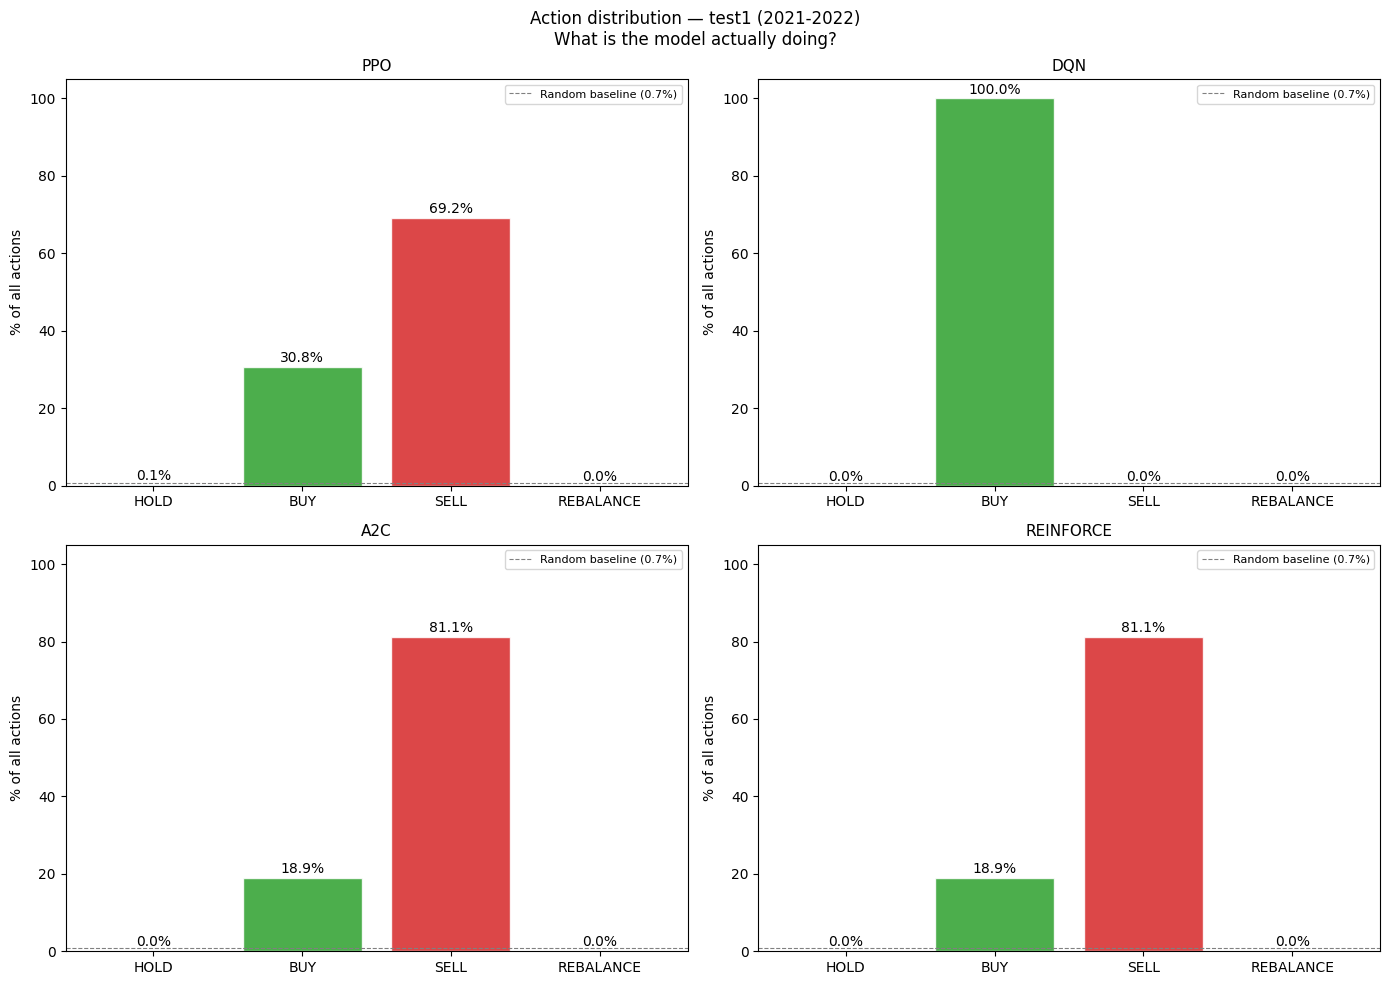

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Action distribution — test1 (2021-2022)\n"
    "What is the model actually doing?",
    fontsize=12
)

colors = {
    "HOLD":      "#1f77b4",
    "BUY":       "#2ca02c",
    "SELL":      "#d62728",
    "REBALANCE": "#ff7f0e",
}

for ax, (algo, res) in zip(axes.flatten(), action_results.items()):
    categories = ["HOLD", "BUY", "SELL", "REBALANCE"]
    values     = [
        res["hold_pct"],
        res["buy_pct"],
        res["sell_pct"],
        res["rebalance_pct"],
    ]
    bar_colors = [colors[c] for c in categories]
    bars = ax.bar(categories, values, color=bar_colors, alpha=0.85,
                  edgecolor="white")

    # Label each bar
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}%",
            ha="center", va="bottom", fontsize=10
        )

    ax.set_title(f"{algo.upper()}", fontsize=11)
    ax.set_ylabel("% of all actions")
    ax.set_ylim(0, 105)
    ax.axhline(100 / 136, color="gray", lw=0.8, ls="--",
               label=f"Random baseline ({100/136:.1f}%)")
    ax.legend(fontsize=8)

plt.tight_layout()
os.makedirs(str(PLOTS_DIR), exist_ok=True)
plt.savefig(str(PLOTS_DIR / "action_distribution.png"),
            dpi=130, bbox_inches="tight")
plt.show()
print("Saved: action_distribution.png")

NameError: name 'PLOTS_DIR' is not defined

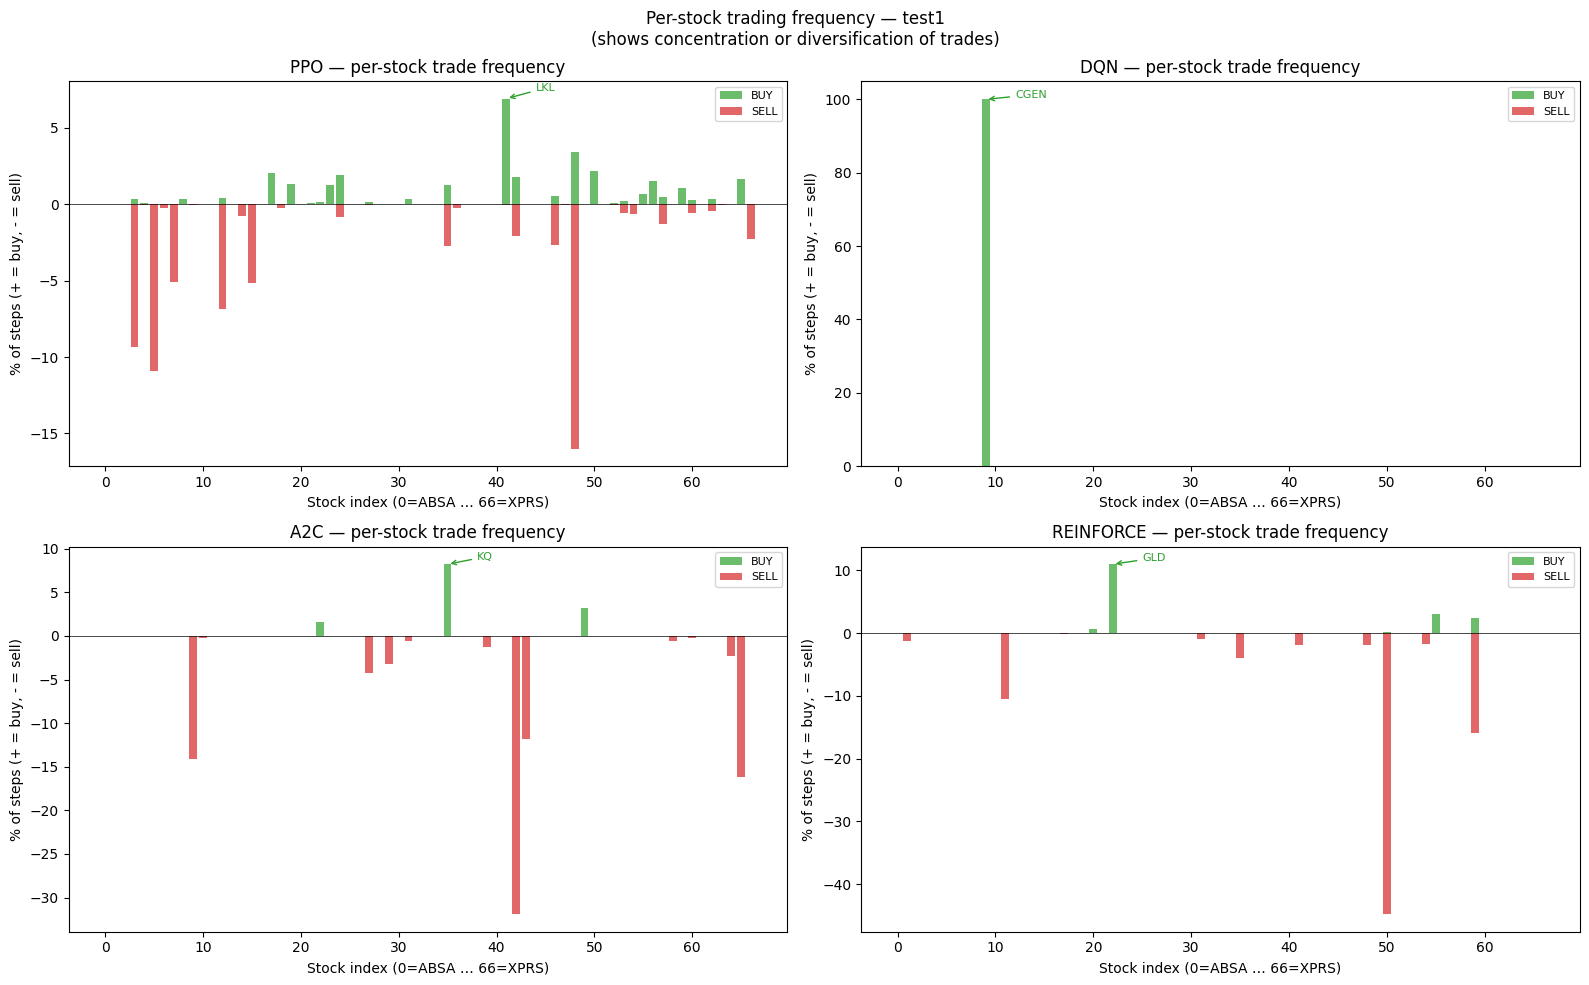

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "Per-stock trading frequency — test1\n"
    "(shows concentration or diversification of trades)",
    fontsize=12
)

for ax, (algo, res) in zip(axes.flatten(), action_results.items()):
    counts  = res["counts"]
    total   = res["total"]

    # Buy frequency per stock
    buy_freq  = np.zeros(N)
    sell_freq = np.zeros(N)
    for action, cnt in counts.items():
        if action < N:
            buy_freq[action]       = cnt / total * 100
        elif action < N * 2:
            sell_freq[action - N]  = cnt / total * 100

    x = np.arange(N)
    ax.bar(x, buy_freq,         color="#2ca02c", alpha=0.7, label="BUY")
    ax.bar(x, -sell_freq,       color="#d62728", alpha=0.7, label="SELL")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"{algo.upper()} — per-stock trade frequency")
    ax.set_xlabel("Stock index (0=ABSA … 66=XPRS)")
    ax.set_ylabel("% of steps (+ = buy, - = sell)")
    ax.legend(fontsize=8)

    # Mark the most traded stock
    most_bought = int(np.argmax(buy_freq))
    most_sold   = int(np.argmax(sell_freq))
    if buy_freq[most_bought] > 0:
        ax.annotate(ALL_TICKERS[most_bought],
                    xy=(most_bought, buy_freq[most_bought]),
                    xytext=(most_bought + 3, buy_freq[most_bought] + 0.5),
                    fontsize=8, color="#2ca02c",
                    arrowprops=dict(arrowstyle="->", color="#2ca02c"))

plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "per_stock_trading.png"),
            dpi=130, bbox_inches="tight")
plt.show()
print("Saved: per_stock_trading.png")

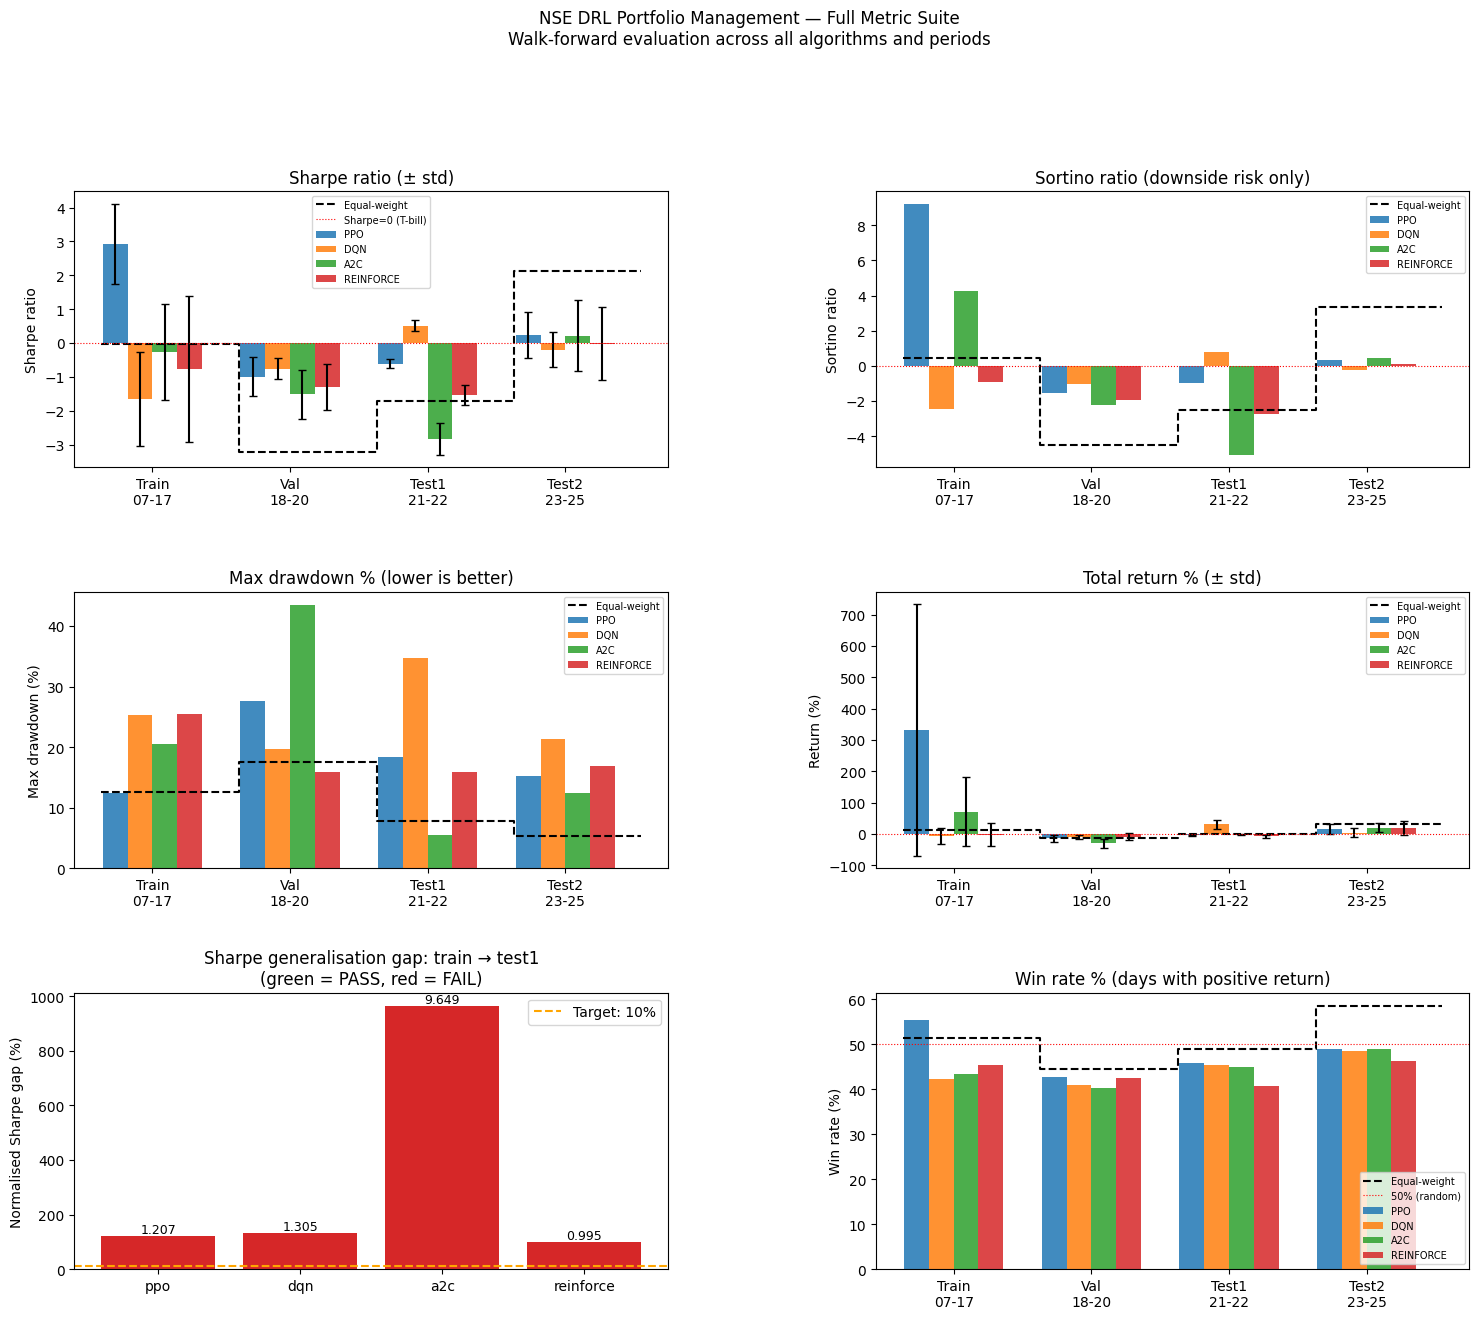

Saved: plots/full_metric_suite.png


In [ ]:
colors  = ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]
algos   = list(all_results.keys())

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

x = np.arange(4)
w = 0.18

# ── Plot 1: Sharpe ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for i, algo in enumerate(algos):
    vals = [all_results[algo][p]["sharpe_mean"] for p in PERIODS]
    errs = [all_results[algo][p]["sharpe_std"]  for p in PERIODS]
    ax1.bar(x + i*w, vals, w, yerr=errs, capsize=3,
            label=algo.upper(), color=colors[i], alpha=0.85)
base = [baselines[p]["sharpe_mean"] for p in PERIODS]
ax1.step(np.append(x - 0.1, x[-1] + len(algos)*w + 0.1),
         np.append(base, base[-1]),
         where="post", color="black", lw=1.5, ls="--", label="Equal-weight")
ax1.axhline(0, color="red", lw=0.8, ls=":", label="Sharpe=0 (T-bill)")
ax1.set_xticks(x + w*1.5)
ax1.set_xticklabels(["Train\n07-17","Val\n18-20","Test1\n21-22","Test2\n23-25"])
ax1.set_title("Sharpe ratio (\u00b1 std)")
ax1.set_ylabel("Sharpe ratio")
ax1.legend(fontsize=7)

# ── Plot 2: Sortino ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for i, algo in enumerate(algos):
    vals = [all_results[algo][p]["sortino_mean"] for p in PERIODS]
    ax2.bar(x + i*w, vals, w, label=algo.upper(), color=colors[i], alpha=0.85)
base = [baselines[p]["sortino_mean"] for p in PERIODS]
ax2.step(np.append(x - 0.1, x[-1] + len(algos)*w + 0.1),
         np.append(base, base[-1]),
         where="post", color="black", lw=1.5, ls="--", label="Equal-weight")
ax2.axhline(0, color="red", lw=0.8, ls=":")
ax2.set_xticks(x + w*1.5)
ax2.set_xticklabels(["Train\n07-17","Val\n18-20","Test1\n21-22","Test2\n23-25"])
ax2.set_title("Sortino ratio (downside risk only)")
ax2.set_ylabel("Sortino ratio")
ax2.legend(fontsize=7)

# ── Plot 3: Max Drawdown ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for i, algo in enumerate(algos):
    vals = [all_results[algo][p]["mdd_mean"] for p in PERIODS]
    ax3.bar(x + i*w, vals, w, label=algo.upper(), color=colors[i], alpha=0.85)
base = [baselines[p]["mdd_mean"] for p in PERIODS]
ax3.step(np.append(x - 0.1, x[-1] + len(algos)*w + 0.1),
         np.append(base, base[-1]),
         where="post", color="black", lw=1.5, ls="--", label="Equal-weight")
ax3.set_xticks(x + w*1.5)
ax3.set_xticklabels(["Train\n07-17","Val\n18-20","Test1\n21-22","Test2\n23-25"])
ax3.set_title("Max drawdown % (lower is better)")
ax3.set_ylabel("Max drawdown (%)")
ax3.legend(fontsize=7)

# ── Plot 4: Return ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
for i, algo in enumerate(algos):
    vals = [all_results[algo][p]["return_mean"] for p in PERIODS]
    errs = [all_results[algo][p]["return_std"]  for p in PERIODS]
    ax4.bar(x + i*w, vals, w, yerr=errs, capsize=3,
            label=algo.upper(), color=colors[i], alpha=0.85)
base = [baselines[p]["return_mean"] for p in PERIODS]
ax4.step(np.append(x - 0.1, x[-1] + len(algos)*w + 0.1),
         np.append(base, base[-1]),
         where="post", color="black", lw=1.5, ls="--", label="Equal-weight")
ax4.axhline(0, color="red", lw=0.8, ls=":")
ax4.set_xticks(x + w*1.5)
ax4.set_xticklabels(["Train\n07-17","Val\n18-20","Test1\n21-22","Test2\n23-25"])
ax4.set_title("Total return % (\u00b1 std)")
ax4.set_ylabel("Return (%)")
ax4.legend(fontsize=7)

# ── Plot 5: Generalisation Gap ──────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
gaps       = [gap_results[a]["normalised_gap"] for a in algos]
bar_colors = ["#2ca02c" if g < 0.10 else "#d62728" for g in gaps]
bars = ax5.bar(algos, [g * 100 for g in gaps], color=bar_colors)
ax5.axhline(10, color="orange", lw=1.5, ls="--", label="Target: 10%")
ax5.set_ylabel("Normalised Sharpe gap (%)")
ax5.set_title("Sharpe generalisation gap: train \u2192 test1\n(green = PASS, red = FAIL)")
ax5.legend()
for bar, g in zip(bars, gaps):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{g:.3f}", ha="center", va="bottom", fontsize=9)

# ── Plot 6: Win Rate ────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
for i, algo in enumerate(algos):
    vals = [all_results[algo][p]["winrate_mean"] for p in PERIODS]
    ax6.bar(x + i*w, vals, w, label=algo.upper(), color=colors[i], alpha=0.85)
base = [baselines[p]["winrate_mean"] for p in PERIODS]
ax6.step(np.append(x - 0.1, x[-1] + len(algos)*w + 0.1),
         np.append(base, base[-1]),
         where="post", color="black", lw=1.5, ls="--", label="Equal-weight")
ax6.axhline(50, color="red", lw=0.8, ls=":", label="50% (random)")
ax6.set_xticks(x + w*1.5)
ax6.set_xticklabels(["Train\n07-17","Val\n18-20","Test1\n21-22","Test2\n23-25"])
ax6.set_title("Win rate % (days with positive return)")
ax6.set_ylabel("Win rate (%)")
ax6.legend(fontsize=7)

plt.suptitle(
    "NSE DRL Portfolio Management — Full Metric Suite\n"
    "Walk-forward evaluation across all algorithms and periods",
    fontsize=12, y=1.01
)
plt.savefig("plots/full_metric_suite.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: plots/full_metric_suite.png")

## Per-algorithm radar / spider chart

Shows all six metrics for each algorithm on test1 relative to the baseline.
Values above 1.0 on each axis mean the algorithm beat the baseline on that metric.


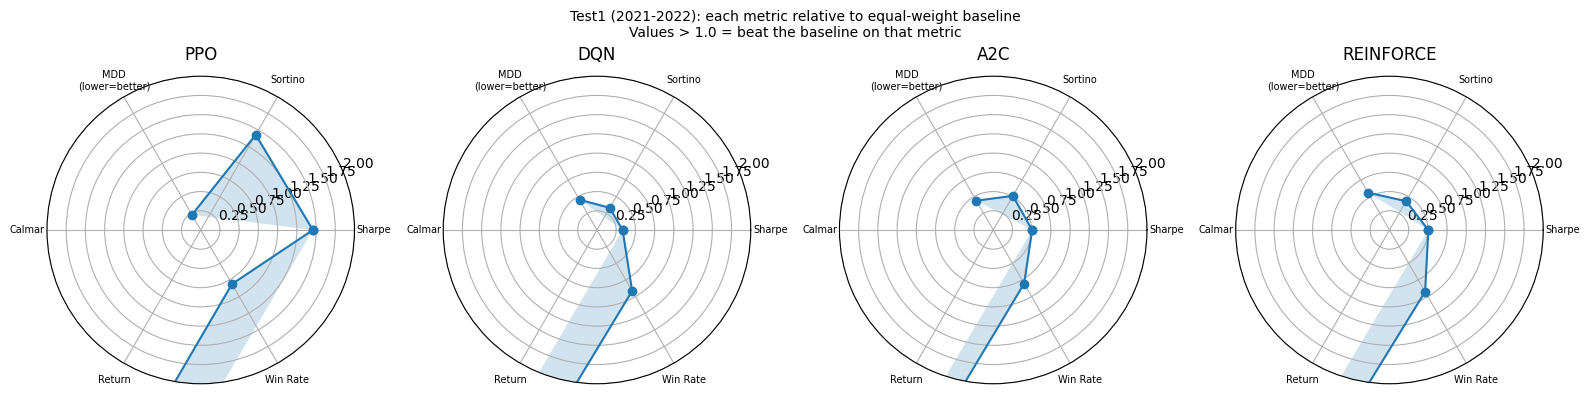

Saved: plots/radar_vs_baseline.png


In [ ]:
from matplotlib.patches import FancyArrowPatch

metric_keys    = ["sharpe_mean","sortino_mean","mdd_mean","calmar_mean","return_mean","winrate_mean"]
metric_labels  = ["Sharpe","Sortino","MDD\n(lower=better)","Calmar","Return","Win Rate"]
higher_better  = [True, True, False, True, True, True]

fig, axes = plt.subplots(1, len(algos), figsize=(16, 4),
                          subplot_kw={"projection": "polar"})

angles = np.linspace(0, 2*np.pi, len(metric_keys), endpoint=False).tolist()
angles += angles[:1]

for ax, algo in zip(axes, algos):
    res_t1   = all_results[algo]["test1"]
    base_t1  = baselines["test1"]

    # Normalise each metric relative to baseline (baseline = 1.0)
    vals = []
    for mk, hb in zip(metric_keys, higher_better):
        agent_v = res_t1[mk]
        base_v  = base_t1[mk]
        if base_v == 0:
            norm = 1.0
        elif hb:
            norm = agent_v / base_v if base_v != 0 else 1.0
        else:
            # lower is better: flip so > 1 = better than baseline
            norm = base_v / agent_v if agent_v != 0 else 1.0
        vals.append(norm)

    vals += vals[:1]

    ax.plot(angles, vals, "o-", lw=1.5, color="#1f77b4")
    ax.fill(angles, vals, alpha=0.2, color="#1f77b4")
    ax.axhline(y=1.0, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels, fontsize=7)
    ax.set_title(algo.upper(), pad=12)
    ax.set_ylim(0, 2)
    ax.axhline(y=1.0, color="gray", lw=0.8, ls="--")

plt.suptitle(
    "Test1 (2021-2022): each metric relative to equal-weight baseline\n"
    "Values > 1.0 = beat the baseline on that metric",
    fontsize=10
)
plt.tight_layout()
plt.savefig("plots/radar_vs_baseline.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: plots/radar_vs_baseline.png")

## Save all results

In [ ]:
import os, json

os.makedirs(str(MODELS_DIR), exist_ok=True)

output = {
    "algorithm_results":      all_results,
    "generalisation_gaps":    gap_results,
    "equal_weight_baselines": baselines,
    "nse_context":            sharpe_context_nse(),
}

save_path = MODELS_DIR / "backtest_results.json"

with open(str(save_path), "w") as f:
    json.dump(output, f, indent=2, default=str)

print(f"Saved: {save_path}")
print()
print("=" * 55)
print("BACKTEST COMPLETE")
print("=" * 55)
print()
print("Metrics reported:")
print("  Sharpe ratio        — primary risk-adjusted metric")
print("  Sortino ratio       — downside risk only (more appropriate for NSE)")
print("  Max drawdown        — most important for retail investors")
print("  Calmar ratio        — return per unit of drawdown risk")
print("  Total return %      — raw performance")
print("  Win rate %          — % of profitable days")

Saved: c:\Users\Administrator\nse_portfolio_rl\training\models\backtest_results.json

BACKTEST COMPLETE

Metrics reported:
  Sharpe ratio        — primary risk-adjusted metric
  Sortino ratio       — downside risk only (more appropriate for NSE)
  Max drawdown        — most important for retail investors
  Calmar ratio        — return per unit of drawdown risk
  Total return %      — raw performance
  Win rate %          — % of profitable days
